# Spectral Analysis — Phase 8: GSM8K Normalization Ablation + GPQA Diamond (72B)

**Part A:** Re-run Phase 7 feature fusion with z-score normalization fix.  
Compare: unnormalized Nadler (Phase 7 baseline 76.0%) vs normalized Nadler vs simple average.

**Part B:** GPQA Diamond inference with Qwen2.5-72B-Instruct (4-bit).  
Prior GPQA (7B models) was ~65% AUC — weak because model accuracy was only ~30%.  
Qwen2.5-72B reaches ~65% accuracy on GPQA → expect meaningful spectral signal.

**Drive base dir:** `/content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/`

In [1]:
# ── Install & imports ──────────────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'transformers>=4.40', 'datasets',
                'accelerate', 'scipy', 'bitsandbytes'], check=True)

import os, gc, re, itertools, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from scipy.linalg import eigh
from scipy.signal import stft as scipy_stft
from tqdm import tqdm
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'font.size': 11, 'axes.titlesize': 13})
COLORS = {'our_norm': '#2166ac', 'our_unnorm': '#74add1', 'lapei_sup': '#d73027',
          'lapei_unsup': '#f4a582', 'baseline': '#aaaaaa'}

# ── I/O ────────────────────────────────────────────────────────────────────────
def load_cache(path):
    return pickle.load(open(path, 'rb')) if os.path.exists(path) else {}

def save_cache(obj, path):
    pickle.dump(obj, open(path, 'wb'))

def free_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ── Feature extraction ─────────────────────────────────────────────────────────
def compute_spectral_features(ents, min_len=8):
    e = np.array(ents, dtype=float); N = len(e)
    if N < min_len: return None
    e_ac = e - e.mean()
    fft_vals = np.fft.rfft(e_ac)
    psd = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(N)
    psd_sum = psd.sum() + 1e-12
    psd_norm = psd / psd_sum
    spec_ent = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
    low_mask = (freqs > 0.0) & (freqs <= 0.10)
    high_mask = (freqs >= 0.40) & (freqs <= 0.50)
    low_power = psd[low_mask].sum() / psd_sum
    high_power = psd[high_mask].sum() / psd_sum
    hl_ratio = high_power / (low_power + 1e-12)
    ac_mask = freqs > 0
    dom_freq = float(freqs[ac_mask][np.argmax(psd[ac_mask])]) if ac_mask.sum() > 0 else 0.0
    centroid = float(np.sum(freqs[ac_mask] * psd_norm[ac_mask]) /
                     (psd_norm[ac_mask].sum() + 1e-12)) if ac_mask.sum() > 0 else 0.0
    return {'spectral_entropy': float(spec_ent), 'low_band_power': float(low_power),
            'high_band_power': float(high_power), 'hl_ratio': float(hl_ratio),
            'dominant_freq': dom_freq, 'spectral_centroid': centroid}

def compute_stft_features(ents, nperseg=16, noverlap=8, min_len=32):
    e = np.array(ents, dtype=float)
    if len(e) < min_len:
        return {'stft_max_high_power': 0.0, 'stft_spectral_entropy': 0.0}
    e_ac = e - e.mean()
    f, t, Zxx = scipy_stft(e_ac, nperseg=nperseg, noverlap=noverlap)
    psd = np.abs(Zxx) ** 2
    high_mask = f >= 0.40
    if high_mask.sum() > 0 and psd.shape[1] > 0:
        high_frac = psd[high_mask].sum(0) / (psd.sum(0) + 1e-12)
        max_local_high = float(high_frac.max())
    else:
        max_local_high = 0.0
    psd_n = psd / (psd.sum(0, keepdims=True) + 1e-12)
    frame_ent = -np.sum(psd_n * np.log(psd_n + 1e-12), axis=0)
    stft_ent = float(frame_ent.mean()) if len(frame_ent) > 0 else 0.0
    return {'stft_max_high_power': max_local_high, 'stft_spectral_entropy': stft_ent}

def compute_time_domain(ents, tail_frac=0.20, sw_window=16, sw_step=1):
    e = np.array(ents, dtype=float)
    W = max(1, int(len(e) * tail_frac))
    rpdi = float(e[-W:].mean() / (e.mean() + 1e-12))
    if len(e) >= sw_window:
        sw_vars = [np.var(e[i:i+sw_window])
                   for i in range(0, len(e)-sw_window+1, sw_step)]
        sw_var_peak = float(np.max(sw_vars))
    else:
        sw_var_peak = float(np.var(e))
    return {'rpdi': rpdi, 'sw_var_peak': sw_var_peak}

def extract_all_features(ents):
    e = np.array(ents, dtype=float)
    result = {'epr': float(e.mean()), 'trace_length': float(len(e))}
    gf = compute_spectral_features(ents)
    if gf is None: return None
    result.update(gf)
    result.update(compute_stft_features(ents))
    result.update(compute_time_domain(ents))
    return result

def sw_var_peak_with_window(ents, sw_window, sw_step=1):
    e = np.array(ents, dtype=float)
    if len(e) >= sw_window:
        return float(np.max([np.var(e[i:i+sw_window])
                              for i in range(0, len(e)-sw_window+1, sw_step)]))
    return float(np.var(e))

FEAT_NAMES = ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power',
              'hl_ratio', 'dominant_freq', 'spectral_centroid',
              'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak']

# ── Statistics ─────────────────────────────────────────────────────────────────
def zscore(x):
    x = np.array(x, dtype=float)
    s = x.std()
    return (x - x.mean()) / (s + 1e-12)

def boot_auc(y, scores, n=1000):
    y, s = np.array(y), np.array(scores)
    if len(np.unique(y)) < 2 or np.std(s) < 1e-8:
        return float('nan'), float('nan'), float('nan')
    base = roc_auc_score(y, s)
    rng = np.random.default_rng(42)
    boots = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2: continue
        boots.append(roc_auc_score(y[idx], s[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5]) if boots else (base, base)
    return base, lo, hi

def nadler_fuse(*views):
    X = np.column_stack(views); n, k = X.shape
    C = np.cov(X.T)
    if C.ndim == 0: C = np.array([[float(C)]])
    try:
        off = C - np.diag(np.diag(C))
        rs, cs = off.sum(1), off.sum(0)
        M = np.diag(rs) @ np.linalg.pinv(C) @ np.diag(cs)
        _, vecs = eigh(M)
        w = np.abs(vecs[:, -1]); w /= w.sum() + 1e-12
    except Exception:
        w = np.ones(k) / k
    return X @ w, w

def simple_average_fusion(*views):
    X = np.column_stack(views)
    w = np.ones(X.shape[1]) / X.shape[1]
    return X @ w, w

def best_nadler_on(feats_dict, feat_names, labels_, max_size=4, label='',
                   normalize=True, compare_mean=False):
    """Normalized Nadler fusion. normalize=True applies zscore per feature."""
    auc_m, sign_m = {}, {}
    for n_ in feat_names:
        ap, *_ = boot_auc(labels_,  feats_dict[n_])
        an, *_ = boot_auc(labels_, -feats_dict[n_])
        if ap >= an: auc_m[n_], sign_m[n_] = ap, +1
        else:        auc_m[n_], sign_m[n_] = an, -1
    if normalize:
        oriented = {n_: zscore(feats_dict[n_] * sign_m[n_]) for n_ in feat_names}
    else:
        oriented = {n_: feats_dict[n_] * sign_m[n_] for n_ in feat_names}
    rho = {}
    for a, b in itertools.combinations_with_replacement(feat_names, 2):
        r, _ = spearmanr(oriented[a], oriented[b])
        rho[(a, b)] = rho[(b, a)] = r
    info = [n_ for n_ in feat_names if auc_m[n_] > 0.50]
    total_combos = sum(sum(1 for _ in itertools.combinations(info, size))
                       for size in range(2, min(len(info)+1, max_size+1)))
    print(f'  [{label}] {len(feat_names)} features, {len(info)} informative, '
          f'max_size={max_size} → {total_combos} raw combos')
    best_a, best_lo, best_hi, best_s, best_w = 0.0, 0.0, 0.0, None, None
    checked, skipped = 0, 0
    for size in range(2, min(len(info)+1, max_size+1)):
        size_combos = list(itertools.combinations(info, size))
        valid_in_size = 0
        for s in size_combos:
            if any(abs(rho[(a, b)]) >= 0.75 for a, b in itertools.combinations(s, 2)):
                skipped += 1; continue
            fused, w_n = nadler_fuse(*[oriented[n_] for n_ in s])
            a, lo, hi = boot_auc(labels_, fused)
            if a > best_a: best_a, best_lo, best_hi, best_s, best_w = a, lo, hi, s, w_n
            checked += 1; valid_in_size += 1
        print(f'    size={size}: {len(size_combos)} combos, {valid_in_size} passed ρ-filter, '
              f'best so far={100*best_a:.1f}%')
    print(f'  [{label}] done — checked={checked}, skipped(ρ)={skipped}, best={100*best_a:.1f}%')
    if compare_mean and best_s is not None:
        fused_avg, _ = simple_average_fusion(*[oriented[n_] for n_ in best_s])
        avg_a, avg_lo, avg_hi = boot_auc(labels_, fused_avg)
        lift = (best_a - avg_a) * 100
        print(f'\n  Nadler Lift over simple average (subset: {" + ".join(best_s)}):')
        print(f'    Nadler : {100*best_a:.1f}%  [{100*best_lo:.1f}, {100*best_hi:.1f}]')
        print(f'    Mean   : {100*avg_a:.1f}%  [{100*avg_lo:.1f}, {100*avg_hi:.1f}]')
        print(f'    Lift   : {lift:+.1f} pp')
    return best_a, best_lo, best_hi, best_s, best_w

# ── Model loading / generation ─────────────────────────────────────────────────
def load_model(model_id, quantize_4bit=False):
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    if quantize_4bit:
        bnb_cfg = BitsAndBytesConfig(load_in_4bit=True,
                                     bnb_4bit_compute_dtype=torch.float16,
                                     bnb_4bit_use_double_quant=True,
                                     bnb_4bit_quant_type='nf4')
        mdl = AutoModelForCausalLM.from_pretrained(
            model_id, quantization_config=bnb_cfg,
            device_map='auto', trust_remote_code=True)
    else:
        mdl = AutoModelForCausalLM.from_pretrained(
            model_id, device_map='auto', dtype=torch.float16, trust_remote_code=True)
    mdl.eval()
    print(f'Loaded {model_id}')
    if torch.cuda.is_available():
        mem_gb = torch.cuda.memory_allocated() / 1e9
        total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'GPU memory: {mem_gb:.1f} GB used / {total_gb:.0f} GB total')
    return mdl, tok

def fmt_prompt(tok, msg):
    try:
        return tok.apply_chat_template([{'role': 'user', 'content': msg}],
                                       tokenize=False, add_generation_prompt=True)
    except:
        return f'<|user|>\n{msg}\n<|assistant|>\n'

def token_entropies_from_scores(scores, K=15):
    ents = []
    for s in scores:
        lp = F.log_softmax(s[0], dim=-1)
        topk = torch.topk(lp, min(K, lp.shape[-1])).values
        p = torch.exp(topk); p = p / (p.sum() + 1e-12)
        ents.append(-(p * torch.log(p + 1e-12)).sum().item())
    return ents

def generate_full(mdl, tok, prompt_msg, temperature=1.0, K=15, max_new_tokens=512):
    prompt = fmt_prompt(tok, prompt_msg)
    inputs = tok(prompt, return_tensors='pt').to(mdl.device)
    if 'token_type_ids' in inputs: del inputs['token_type_ids']
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                           do_sample=True, temperature=temperature, top_k=50,
                           output_scores=True, return_dict_in_generate=True,
                           pad_token_id=tok.eos_token_id)
    gen_ids = out.sequences[0][inputs.input_ids.shape[1]:]
    full_text = tok.decode(gen_ids, skip_special_tokens=True).strip()
    all_ents = token_entropies_from_scores(out.scores, K)
    return full_text, all_ents

print('All helpers defined. Phase 8 ready.')

All helpers defined. Phase 8 ready.


In [2]:
# ── Mount Drive + Config ───────────────────────────────────────────────────────
from google.colab import drive, userdata
drive.mount('/content/drive')

try:
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=False)
    print('HuggingFace login OK.')
except Exception as e:
    print(f'HF login skipped: {e}')

RUN_DIR  = '/content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/Llama-3.1-8B-Instruct__gsm8k_T1.0/'
PLOT_DIR = '/content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/'
os.makedirs(PLOT_DIR, exist_ok=True)

# Reference constants
LAPEI_SUPERVISED   = 0.872   # Table 1, supervised
LAPEI_UNSUPERVISED = 0.720   # AttentionScore, unsupervised
PHASE7_UNNORM      = 0.760   # Our Phase 7 unnormalized result
SEMANTIC_ENTROPY   = 0.700   # Semantic Entropy literature baseline
EPR_MEAN           = 0.707   # Our 'epr' feature individual AUC (Phase 7)

print(f'Drive mounted. Plot dir ready: {PLOT_DIR}')

Mounted at /content/drive
HuggingFace login OK.
Drive mounted. Plot dir ready: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/


In [3]:
# ── Load Phase 7 Data ──────────────────────────────────────────────────────────
import json

RESULTS_PATH = os.path.join(RUN_DIR, 'phase7_results.pkl')
CACHE_PATH   = os.path.join(RUN_DIR, 'inference_cache.pkl')

results = load_cache(RESULTS_PATH)
cache   = load_cache(CACHE_PATH)

assert results, f'phase7_results.pkl not found at {RESULTS_PATH}'
assert cache,   f'inference_cache.pkl not found at {CACHE_PATH}'

labels      = np.array(results['raw_labels'])
feat_arrays = {k: np.array(v) for k, v in results['feat_arrays'].items()}
feat_names  = results['feat_names']
ablation_data = results['ablation']   # list of {w, auc, lo, hi}

# Rebuild raw entropy traces from cache
raw_ents = []
for i in sorted(k for k in cache if isinstance(cache[k].get('done'), bool) and cache[k]['done']):
    v = cache[i]
    if v.get('all_entropies') and len(v['all_entropies']) >= 8:
        raw_ents.append(v['all_entropies'])

n_toks = np.array([len(e) for e in raw_ents])

print(f'Loaded {len(labels)} samples | {int(labels.sum())} correct ({labels.mean():.1%}) | '
      f'avg trace {n_toks.mean():.1f} tok')
print(f'Phase 7 unnormalized Nadler: {100*PHASE7_UNNORM:.1f}% [72.5, 79.3]')
print(f'Phase 7 best subset: trace_length + low_band_power + stft_spectral_entropy + sw_var_peak')
print(f'Window ablation data: {len(ablation_data)} window sizes')

UNNORM_SUBSET = tuple(results['subset_results'][0]['subset']) if results.get('subset_results') else \
    ('trace_length', 'low_band_power', 'stft_spectral_entropy', 'sw_var_peak')

Loaded 1319 samples | 1043 correct (79.1%) | avg trace 193.6 tok
Phase 7 unnormalized Nadler: 76.0% [72.5, 79.3]
Phase 7 best subset: trace_length + low_band_power + stft_spectral_entropy + sw_var_peak
Window ablation data: 5 window sizes


In [4]:
# ── Individual Feature AUCs (normalization-invariant — rank-based) ─────────────
# AUC depends only on rank order, which zscore preserves → identical normalized/unnormalized.
feat_aucs = {}
rows_ind = []
for fn in feat_names:
    ap, lop, hip = boot_auc(labels,  feat_arrays[fn])
    an, lon, hin = boot_auc(labels, -feat_arrays[fn])
    if ap >= an:
        feat_aucs[fn] = (ap, lop, hip, +1)
    else:
        feat_aucs[fn] = (an, lon, hin, -1)
    rows_ind.append((feat_aucs[fn][0], fn, feat_aucs[fn][1], feat_aucs[fn][2]))

rows_ind.sort(reverse=True)

print(f'Individual Feature AUCs — GSM8K / Llama-3.1-8B T=1.0')
print(f'  (Normalization-invariant: rank-based AUC, baseline for fusion comparison)')
print(f'{"Signal":<26}  {"AUC":>8}  {"95% CI":>16}  {"sign":>5}')
print('-' * 62)
for auc, name, lo, hi in rows_ind:
    sign = feat_aucs[name][3]
    print(f'  {name:<26} {100*auc:>7.1f}%  [{100*lo:>5.1f}, {100*hi:>5.1f}]  {sign:>+4d}')

Individual Feature AUCs — GSM8K / Llama-3.1-8B T=1.0
  (Normalization-invariant: rank-based AUC, baseline for fusion comparison)
Signal                           AUC            95% CI   sign
--------------------------------------------------------------
  sw_var_peak                   73.9%  [ 70.5,  77.5]    +1
  trace_length                  71.5%  [ 67.8,  75.0]    -1
  epr                           70.7%  [ 66.9,  74.6]    -1
  low_band_power                69.3%  [ 65.6,  73.1]    -1
  spectral_centroid             68.0%  [ 64.3,  71.8]    +1
  hl_ratio                      66.3%  [ 62.5,  70.1]    +1
  spectral_entropy              65.0%  [ 61.2,  68.8]    -1
  dominant_freq                 63.0%  [ 59.2,  66.9]    +1
  rpdi                          62.5%  [ 58.6,  66.4]    -1
  high_band_power               60.9%  [ 57.3,  64.8]    +1
  stft_spectral_entropy         57.0%  [ 53.2,  61.0]    +1
  stft_max_high_power           52.7%  [ 48.9,  56.7]    -1


In [5]:
# ── Unnormalized Nadler — Reproduce Phase 7 Baseline ──────────────────────────
# Validates loaded data is correct before comparing normalized vs unnormalized.
print('Reproducing Phase 7 unnormalized Nadler (no zscore)...')
unnorm_auc, unnorm_lo, unnorm_hi, unnorm_subset, unnorm_weights = best_nadler_on(
    feat_arrays, feat_names, labels, max_size=4,
    label='GSM8K-unnormalized', normalize=False, compare_mean=False)

print()
print(f'Unnormalized Nadler: {100*unnorm_auc:.1f}% [{100*unnorm_lo:.1f}, {100*unnorm_hi:.1f}]')
print(f'Best subset: {" + ".join(unnorm_subset)}')

delta_from_p7 = abs(unnorm_auc - PHASE7_UNNORM) * 100
if delta_from_p7 <= 0.5:
    print(f'✓ Matches Phase 7 reported result (Δ={delta_from_p7:.2f} pp ≤ 0.5 pp)')
else:
    print(f'⚠ Deviation from Phase 7: {delta_from_p7:.2f} pp > 0.5 pp — check data.')

Reproducing Phase 7 unnormalized Nadler (no zscore)...
  [GSM8K-unnormalized] 12 features, 12 informative, max_size=4 → 781 raw combos
    size=2: 66 combos, 61 passed ρ-filter, best so far=75.2%
    size=3: 220 combos, 174 passed ρ-filter, best so far=75.7%
    size=4: 495 combos, 309 passed ρ-filter, best so far=76.0%
  [GSM8K-unnormalized] done — checked=544, skipped(ρ)=237, best=76.0%

Unnormalized Nadler: 76.0% [72.5, 79.3]
Best subset: trace_length + low_band_power + stft_spectral_entropy + sw_var_peak
✓ Matches Phase 7 reported result (Δ=0.03 pp ≤ 0.5 pp)


In [6]:
# ── Normalized Nadler — Key Experiment ────────────────────────────────────────
# best_nadler_on applies zscore inside when normalize=True.
# compare_mean=True prints Nadler lift over simple average on best subset.
print('Running normalized Nadler (zscore applied per feature)...')
norm_auc, norm_lo, norm_hi, norm_subset, norm_weights = best_nadler_on(
    feat_arrays, feat_names, labels, max_size=4,
    label='GSM8K-normalized', normalize=True, compare_mean=True)

norm_delta_pp = (norm_auc - unnorm_auc) * 100
print()
print('=' * 55)
print(f'Unnormalized Nadler (Phase 7):  {100*unnorm_auc:.1f}% [{100*unnorm_lo:.1f}, {100*unnorm_hi:.1f}]')
print(f'Normalized Nadler (this run):   {100*norm_auc:.1f}% [{100*norm_lo:.1f}, {100*norm_hi:.1f}]')
print(f'Normalization lift:             {norm_delta_pp:+.1f} pp')
print(f'Best subset: {" + ".join(norm_subset) if norm_subset else "n/a"}')
print('=' * 55)

# Simple average on the normalized best subset (for nadler_lift_pp)
sign_map_norm = {fn: feat_aucs[fn][3] for fn in feat_names}
oriented_z = {fn: zscore(feat_arrays[fn] * sign_map_norm[fn]) for fn in feat_names}
if norm_subset:
    avg_fused, _ = simple_average_fusion(*[oriented_z[fn] for fn in norm_subset])
    avg_auc, avg_lo, avg_hi = boot_auc(labels, avg_fused)
    nadler_lift_pp = (norm_auc - avg_auc) * 100
else:
    avg_auc, avg_lo, avg_hi = 0.0, 0.0, 0.0
    nadler_lift_pp = 0.0

Running normalized Nadler (zscore applied per feature)...
  [GSM8K-normalized] 12 features, 12 informative, max_size=4 → 781 raw combos
    size=2: 66 combos, 61 passed ρ-filter, best so far=75.1%
    size=3: 220 combos, 174 passed ρ-filter, best so far=75.9%
    size=4: 495 combos, 309 passed ρ-filter, best so far=75.9%
  [GSM8K-normalized] done — checked=544, skipped(ρ)=237, best=75.9%

  Nadler Lift over simple average (subset: trace_length + low_band_power + high_band_power + sw_var_peak):
    Nadler : 75.9%  [72.5, 79.4]
    Mean   : 74.2%  [70.8, 77.6]
    Lift   : +1.7 pp

Unnormalized Nadler (Phase 7):  76.0% [72.5, 79.3]
Normalized Nadler (this run):   75.9% [72.5, 79.4]
Normalization lift:             -0.1 pp
Best subset: trace_length + low_band_power + high_band_power + sw_var_peak


In [7]:
# ── All-Subset Comparison Scan (Nadler vs Simple Average) ─────────────────────
# For every valid subset (size 2–4, ρ-filtered), compute both AUCs.
# Uses point estimates (no bootstrap) for speed.

# Orient and z-score once
rho_z = {}
for a, b in itertools.combinations_with_replacement(feat_names, 2):
    r, _ = spearmanr(oriented_z[a], oriented_z[b])
    rho_z[(a, b)] = rho_z[(b, a)] = r

info_feats = [fn for fn in feat_names if feat_aucs[fn][0] > 0.50]

subset_records = []
for size in range(2, 5):
    for s in itertools.combinations(info_feats, size):
        if any(abs(rho_z[(a, b)]) >= 0.75 for a, b in itertools.combinations(s, 2)):
            continue
        fused_n, w_n = nadler_fuse(*[oriented_z[fn] for fn in s])
        fused_a, _   = simple_average_fusion(*[oriented_z[fn] for fn in s])
        auc_n = roc_auc_score(labels, fused_n)
        auc_a = roc_auc_score(labels, fused_a)
        subset_records.append({
            'subset': s, 'size': len(s),
            'nadler_auc': auc_n, 'avg_auc': auc_a,
            'lift': auc_n - auc_a, 'weights': w_n
        })

subset_records.sort(key=lambda x: x['nadler_auc'], reverse=True)
total_valid = len(subset_records)
n_nadler_wins = sum(1 for r in subset_records if r['lift'] > 0)
median_lift = np.median([r['lift'] for r in subset_records]) * 100
mean_lift   = np.mean([r['lift']   for r in subset_records]) * 100

print(f'Scanned {total_valid} valid subsets (size 2–4, ρ-filtered).')
print(f'\nTop 10 by Nadler AUC:')
for i, r in enumerate(subset_records[:10], 1):
    s_str = '+'.join(r['subset'])
    print(f'  {i:2}. {s_str:<60}  Nadler={100*r["nadler_auc"]:.1f}%  '
          f'Avg={100*r["avg_auc"]:.1f}%  Lift={r["lift"]*100:+.1f}pp')

print(f'\nAggregate: median lift={median_lift:+.1f}pp, mean lift={mean_lift:+.1f}pp, '
      f'Nadler > Avg in {100*n_nadler_wins/total_valid:.0f}% of subsets.')

Scanned 544 valid subsets (size 2–4, ρ-filtered).

Top 10 by Nadler AUC:
   1. trace_length+low_band_power+high_band_power+sw_var_peak       Nadler=75.9%  Avg=74.2%  Lift=+1.7pp
   2. trace_length+low_band_power+sw_var_peak                       Nadler=75.9%  Avg=75.8%  Lift=+0.1pp
   3. trace_length+low_band_power+rpdi+sw_var_peak                  Nadler=75.9%  Avg=75.2%  Lift=+0.7pp
   4. trace_length+low_band_power+stft_max_high_power+sw_var_peak   Nadler=75.8%  Avg=74.4%  Lift=+1.4pp
   5. trace_length+low_band_power+stft_spectral_entropy+sw_var_peak  Nadler=75.7%  Avg=74.6%  Lift=+1.1pp
   6. spectral_entropy+low_band_power+stft_max_high_power+sw_var_peak  Nadler=75.7%  Avg=74.3%  Lift=+1.4pp
   7. spectral_entropy+low_band_power+rpdi+sw_var_peak              Nadler=75.7%  Avg=75.0%  Lift=+0.6pp
   8. trace_length+low_band_power+dominant_freq+sw_var_peak         Nadler=75.7%  Avg=74.5%  Lift=+1.2pp
   9. spectral_entropy+low_band_power+sw_var_peak                   Nadler=75.6%  A

In [8]:
# ── Results Summary Table ──────────────────────────────────────────────────────
best_avg_subset = max(subset_records, key=lambda x: x['avg_auc'])
best_avg_auc = best_avg_subset['avg_auc']

print('METHOD                                    AUROC      SUPERVISION    ACCESS')
print('-' * 75)
rows_table = [
    ('LapEigvals supervised (Table 1)',        LAPEI_SUPERVISED,   'Labeled (80%)', 'White-box'),
    (f'Normalized Nadler (this run)',           norm_auc,           'None',          'Gray-box'),
    (f'Unnormalized Nadler (Phase 7)',          PHASE7_UNNORM,      'None',          'Gray-box'),
    (f'Simple average (best norm. subset)',     best_avg_auc,       'None',          'Gray-box'),
    ('LapEigvals unsupervised',                 LAPEI_UNSUPERVISED, 'None',          'White-box'),
    ('Semantic Entropy (Llama-3-8B, lit.)',     SEMANTIC_ENTROPY,   'None',          'Black-box'),
    ("EPR mean (our 'epr' feature)",            EPR_MEAN,           'None',          'Gray-box'),
]
for method, auc, sup, access in rows_table:
    print(f'  {method:<42} {100*auc:>6.1f}%  {sup:<16} {access}')

METHOD                                    AUROC      SUPERVISION    ACCESS
---------------------------------------------------------------------------
  LapEigvals supervised (Table 1)              87.2%  Labeled (80%)    White-box
  Normalized Nadler (this run)                 75.9%  None             Gray-box
  Unnormalized Nadler (Phase 7)                76.0%  None             Gray-box
  Simple average (best norm. subset)           76.3%  None             Gray-box
  LapEigvals unsupervised                      72.0%  None             White-box
  Semantic Entropy (Llama-3-8B, lit.)          70.0%  None             Black-box
  EPR mean (our 'epr' feature)                 70.7%  None             Gray-box


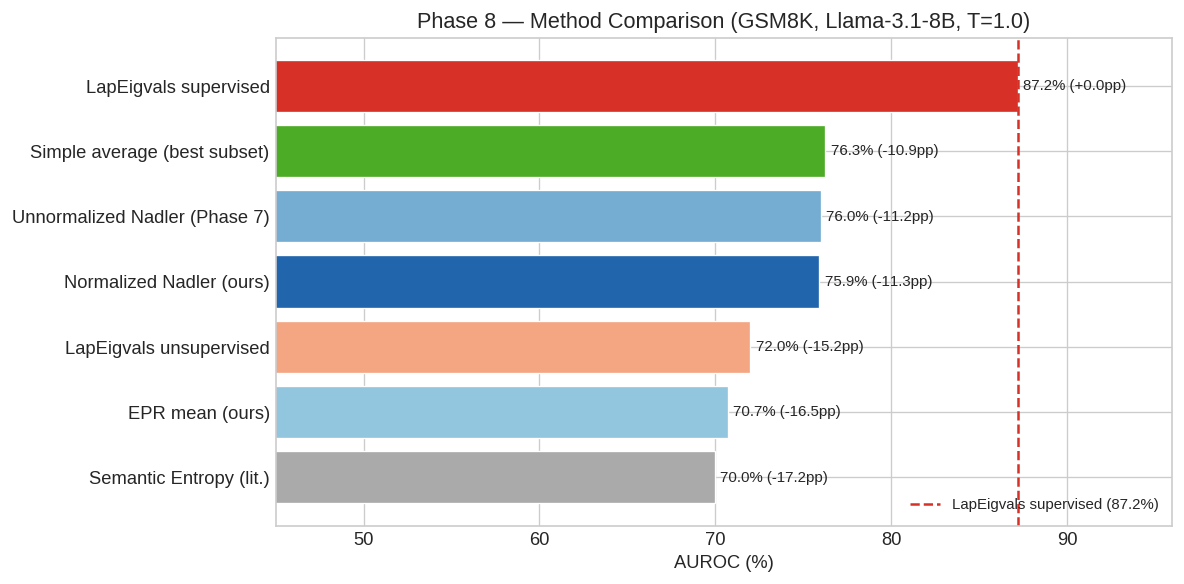

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A1_method_comparison.png


In [9]:
# ── Plot 1: Method Comparison Bar Chart ───────────────────────────────────────
methods_plot = [
    ('LapEigvals supervised',        LAPEI_SUPERVISED,   COLORS['lapei_sup'],   'LapEigvals (sup)'),
    ('Normalized Nadler (ours)',      norm_auc,           COLORS['our_norm'],    'Ours'),
    ('Unnormalized Nadler (Phase 7)', PHASE7_UNNORM,      COLORS['our_unnorm'],  'Ours'),
    ('Simple average (best subset)',  best_avg_auc,       '#4dac26',             'Ours'),
    ('LapEigvals unsupervised',       LAPEI_UNSUPERVISED, COLORS['lapei_unsup'], 'LapEigvals (unsup)'),
    ('Semantic Entropy (lit.)',        SEMANTIC_ENTROPY,   COLORS['baseline'],    'Baseline'),
    ("EPR mean (ours)",               EPR_MEAN,           '#92c5de',             'Ours'),
]
methods_plot.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 5))
names  = [m[0] for m in methods_plot]
aucs   = [100 * m[1] for m in methods_plot]
colors = [m[2] for m in methods_plot]

bars = ax.barh(names, aucs, color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(100 * LAPEI_SUPERVISED, color=COLORS['lapei_sup'], linestyle='--',
           linewidth=1.5, label='LapEigvals supervised (87.2%)')

for bar, auc_val, m in zip(bars, aucs, methods_plot):
    delta = auc_val - 100 * LAPEI_SUPERVISED
    ax.text(auc_val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{auc_val:.1f}% ({delta:+.1f}pp)', va='center', fontsize=9)

ax.set_xlabel('AUROC (%)')
ax.set_title('Phase 8 — Method Comparison (GSM8K, Llama-3.1-8B, T=1.0)')
ax.set_xlim(45, 96)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A1_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A1_method_comparison.png')

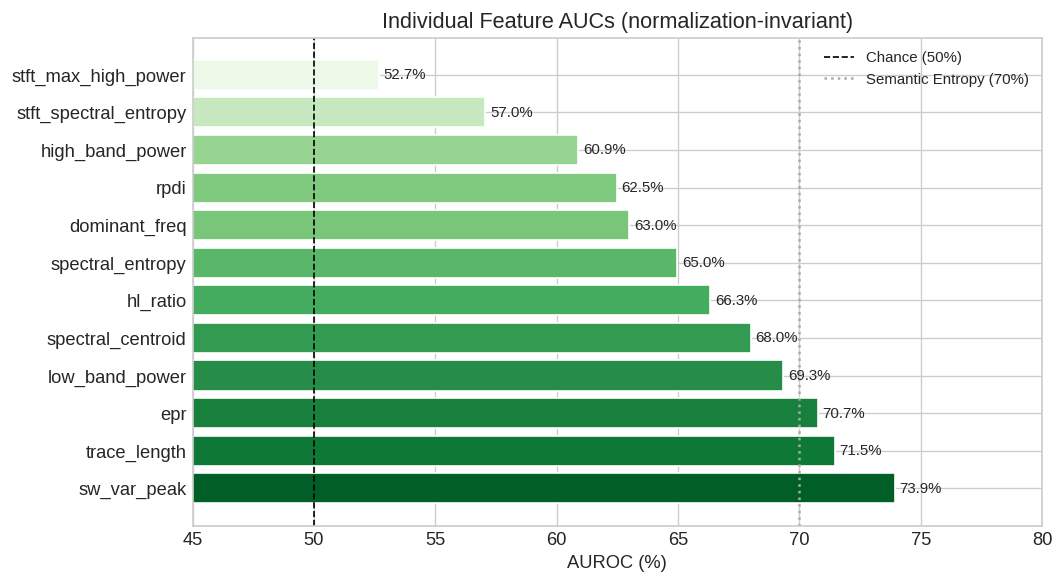

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A2_feature_aucs.png


In [10]:
# ── Plot 2: Individual Feature AUCs ───────────────────────────────────────────
fn_sorted = [name for _, name, _, _ in rows_ind]
auc_sorted = [100 * feat_aucs[fn][0] for fn in fn_sorted]

cmap = plt.cm.Greens
norm_cmap = plt.Normalize(min(auc_sorted) - 2, max(auc_sorted) + 2)
bar_colors = [cmap(norm_cmap(v)) for v in auc_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(fn_sorted, auc_sorted, color=bar_colors, edgecolor='white')
ax.axvline(50, color='black',         linestyle='--', linewidth=1, label='Chance (50%)')
ax.axvline(70, color=COLORS['baseline'], linestyle=':', linewidth=1.5,
           label='Semantic Entropy (70%)')

for bar, v in zip(bars, auc_sorted):
    ax.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{v:.1f}%', va='center', fontsize=9)

ax.set_xlabel('AUROC (%)')
ax.set_title('Individual Feature AUCs (normalization-invariant)')
ax.set_xlim(45, 80)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A2_feature_aucs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A2_feature_aucs.png')

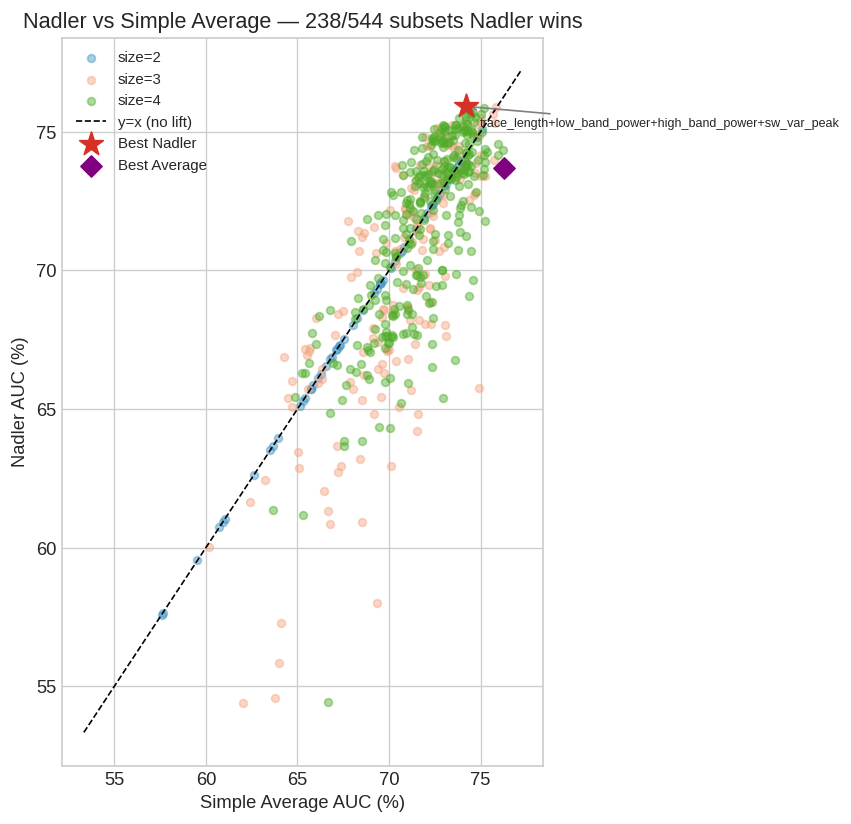

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A3_nadler_vs_average_scatter.png


In [11]:
# ── Plot 3: Nadler vs Average Scatter (All Valid Subsets) ──────────────────────
size_colors = {2: '#4393c3', 3: '#f4a582', 4: '#4dac26'}

fig, ax = plt.subplots(figsize=(7, 7))
for size in [2, 3, 4]:
    recs = [r for r in subset_records if r['size'] == size]
    if not recs: continue
    xs = [100 * r['avg_auc']    for r in recs]
    ys = [100 * r['nadler_auc'] for r in recs]
    ax.scatter(xs, ys, alpha=0.45, s=22, color=size_colors[size], label=f'size={size}')

# y = x diagonal
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=1, label='y=x (no lift)')

# Highlight best Nadler subset
best_rec = subset_records[0]
ax.scatter(100 * best_rec['avg_auc'], 100 * best_rec['nadler_auc'],
           marker='*', s=220, color='#d73027', zorder=5, label='Best Nadler')
ax.annotate('+'.join(best_rec['subset']),
            xy=(100 * best_rec['avg_auc'], 100 * best_rec['nadler_auc']),
            xytext=(8, -12), textcoords='offset points', fontsize=7.5,
            arrowprops=dict(arrowstyle='->', color='grey'))

# Highlight best Average subset
best_avg_r = max(subset_records, key=lambda x: x['avg_auc'])
ax.scatter(100 * best_avg_r['avg_auc'], 100 * best_avg_r['nadler_auc'],
           marker='D', s=80, color='purple', zorder=5, label='Best Average')

n_above = sum(1 for r in subset_records if r['nadler_auc'] > r['avg_auc'])
ax.set_xlabel('Simple Average AUC (%)')
ax.set_ylabel('Nadler AUC (%)')
ax.set_title(f'Nadler vs Simple Average — {n_above}/{total_valid} subsets Nadler wins')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A3_nadler_vs_average_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A3_nadler_vs_average_scatter.png')

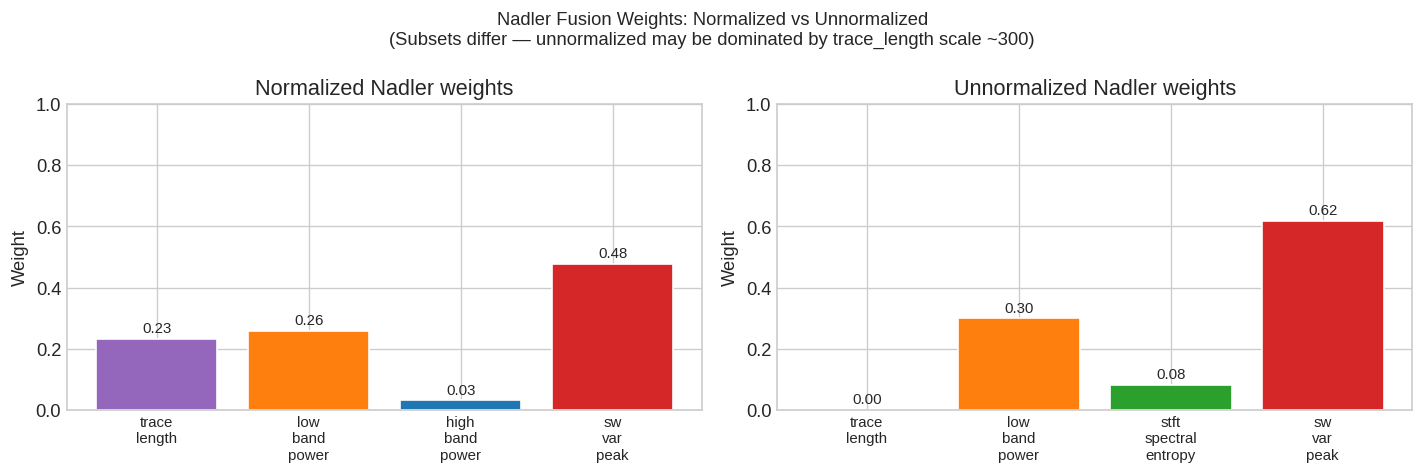

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A4_fusion_weights.png


In [12]:
# ── Plot 4: Fusion Weights Comparison (Normalized vs Unnormalized) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Shared color map so same feature = same color across panels
all_feats_in_plots = list(set(list(norm_subset or []) + list(unnorm_subset or [])))
cpal = plt.cm.tab10.colors
feat_color = {fn: cpal[i % len(cpal)] for i, fn in enumerate(sorted(all_feats_in_plots))}

for ax, subset, weights, title in [
    (axes[0], norm_subset,   norm_weights,   'Normalized Nadler weights'),
    (axes[1], unnorm_subset, unnorm_weights, 'Unnormalized Nadler weights'),
]:
    if subset is None or weights is None:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); continue
    clrs = [feat_color.get(fn, 'grey') for fn in subset]
    bars = ax.bar(range(len(subset)), weights, color=clrs, edgecolor='white')
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels([fn.replace('_', '\n') for fn in subset], fontsize=9)
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    for bar, w in zip(bars, weights):
        ax.text(bar.get_x() + bar.get_width() / 2, w + 0.02,
                f'{w:.2f}', ha='center', fontsize=9)

same_subset = set(norm_subset or []) == set(unnorm_subset or [])
fig.suptitle('Nadler Fusion Weights: Normalized vs Unnormalized\n'
             f'(Subsets {"identical" if same_subset else "differ"} '
             f'— unnormalized may be dominated by trace_length scale ~300)',
             fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A4_fusion_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A4_fusion_weights.png')

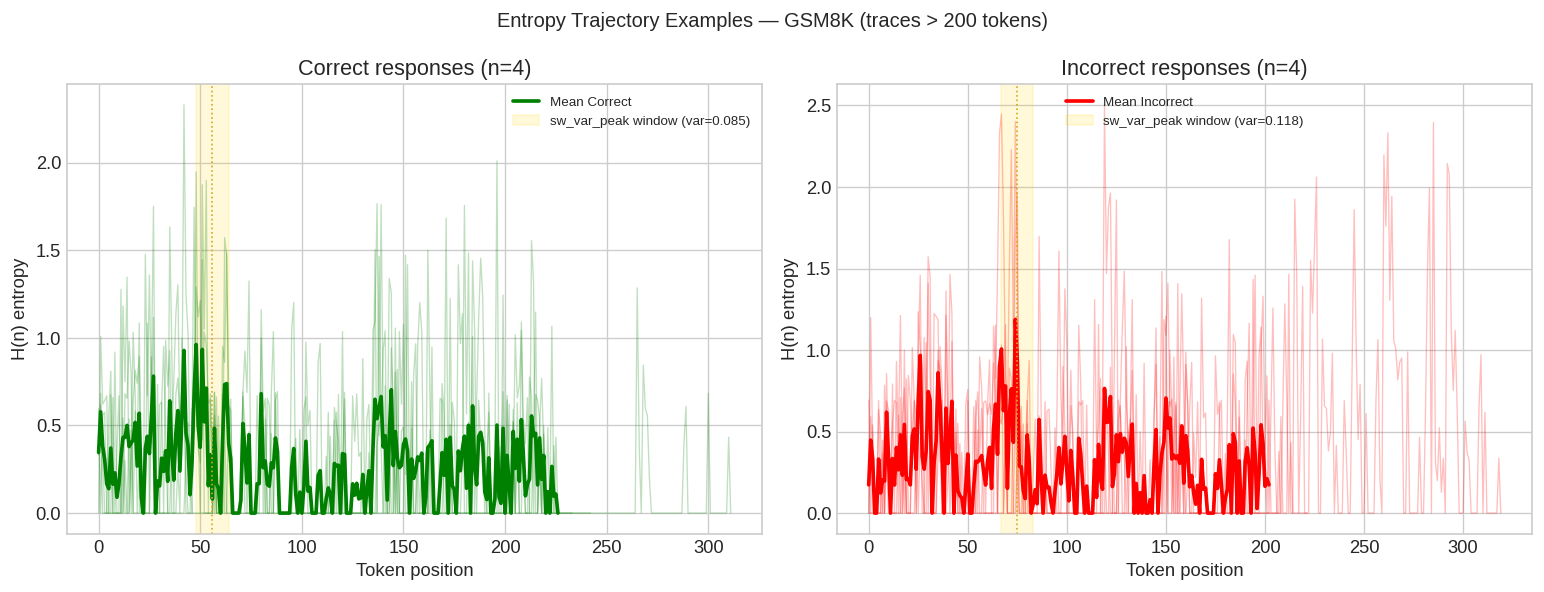

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A5_trajectory_examples.png


In [13]:
# ── Plot 5: H(n) Trajectory Examples ──────────────────────────────────────────
# 4 correct + 4 incorrect traces, length > 200 tokens.
correct_idx   = [i for i, v in enumerate(labels) if v == 1 and len(raw_ents[i]) > 200]
incorrect_idx = [i for i, v in enumerate(labels) if v == 0 and len(raw_ents[i]) > 200]

rng_ex = np.random.default_rng(7)
sel_c = rng_ex.choice(correct_idx,   size=min(4, len(correct_idx)),   replace=False).tolist()
sel_w = rng_ex.choice(incorrect_idx, size=min(4, len(incorrect_idx)), replace=False).tolist()

def sw_var_peak_pos(ents, w=16):
    """Return the start index of the window with maximum variance."""
    e = np.array(ents)
    if len(e) < w: return 0
    idx = np.argmax([np.var(e[i:i+w]) for i in range(len(e)-w+1)])
    return idx

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, idxs, color, label_txt in [
    (axes[0], sel_c, 'green', 'Correct'),
    (axes[1], sel_w, 'red',   'Incorrect'),
]:
    traces = [np.array(raw_ents[i]) for i in idxs]
    min_len = min(len(t) for t in traces) if traces else 0
    for t in traces:
        ax.plot(t, alpha=0.25, linewidth=0.8, color=color)
    if traces:
        mean_tr = np.mean([t[:min_len] for t in traces], axis=0)
        ax.plot(mean_tr, linewidth=2.2, color=color, label=f'Mean {label_txt}')
        peak_pos = sw_var_peak_pos(mean_tr)
        peak_val = np.var(mean_tr[peak_pos:peak_pos+16])
        ax.axvspan(peak_pos, peak_pos+16, alpha=0.15, color='gold',
                   label=f'sw_var_peak window (var={peak_val:.3f})')
        ax.axvline(peak_pos + 8, color='goldenrod', linewidth=1, linestyle=':')
    ax.set_xlabel('Token position')
    ax.set_ylabel('H(n) entropy')
    ax.set_title(f'{label_txt} responses (n={len(idxs)})')
    ax.legend(fontsize=8)

fig.suptitle('Entropy Trajectory Examples — GSM8K (traces > 200 tokens)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A5_trajectory_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A5_trajectory_examples.png')

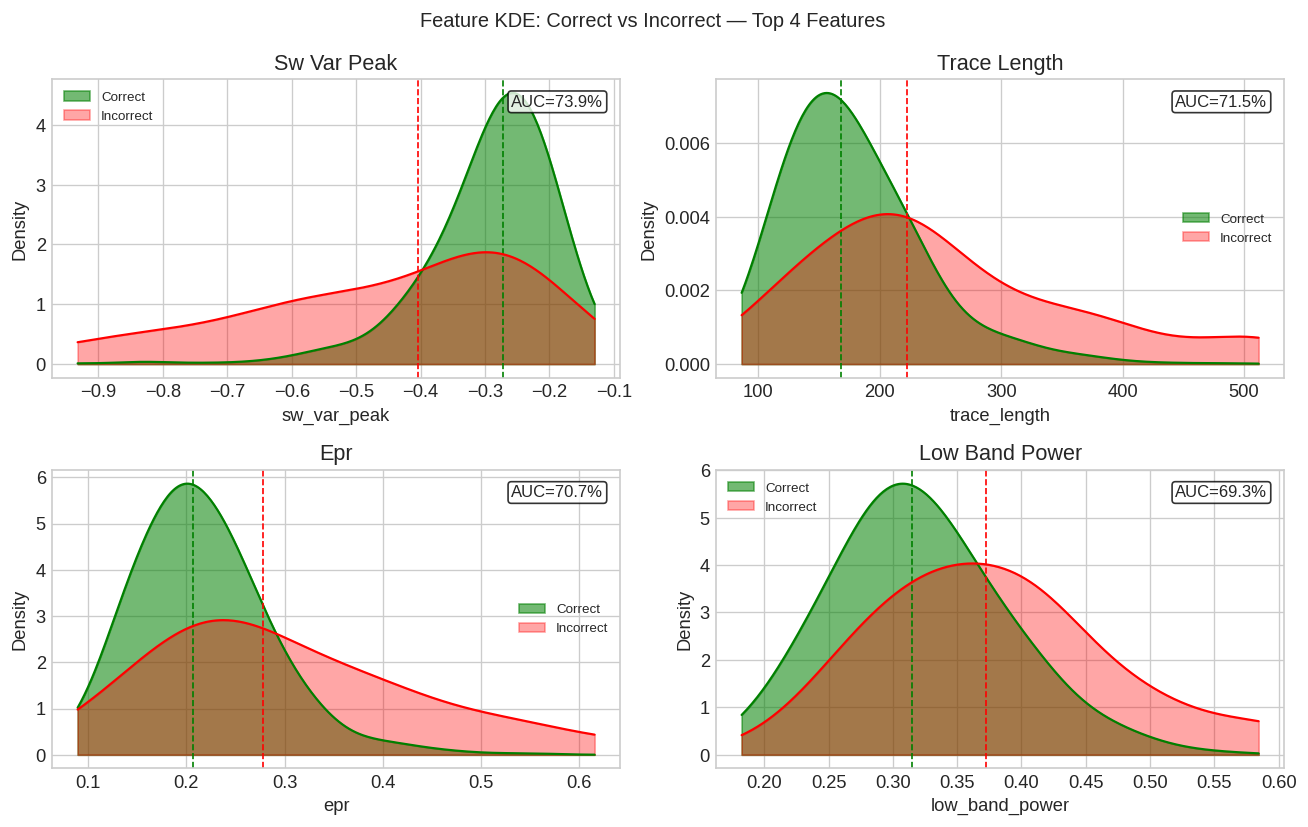

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A6_feature_kde.png


In [14]:
# ── Plot 6: Feature KDE (Correct vs Incorrect) ─────────────────────────────────
from scipy.stats import gaussian_kde

top4 = [name for _, name, _, _ in rows_ind[:4]]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, fn in zip(axes.ravel(), top4):
    vals = feat_arrays[fn]
    v_c = vals[labels == 1]
    v_w = vals[labels == 0]
    xmin, xmax = np.percentile(vals, 1), np.percentile(vals, 99)
    xs = np.linspace(xmin, xmax, 300)

    for v, color, label_txt, alpha in [(v_c, 'green', 'Correct', 0.55),
                                        (v_w, 'red',   'Incorrect', 0.35)]:
        if len(v) > 2:
            kde = gaussian_kde(v, bw_method=0.4)
            dens = kde(xs)
            ax.fill_between(xs, dens, alpha=alpha, color=color, label=label_txt)
            ax.plot(xs, dens, color=color, linewidth=1.3)
            ax.axvline(np.median(v), color=color, linestyle='--', linewidth=1)

    auc_val = feat_aucs[fn][0]
    ax.text(0.97, 0.95, f'AUC={100*auc_val:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.set_xlabel(fn)
    ax.set_ylabel('Density')
    ax.set_title(fn.replace('_', ' ').title())
    ax.legend(fontsize=8)

fig.suptitle('Feature KDE: Correct vs Incorrect — Top 4 Features', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A6_feature_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A6_feature_kde.png')

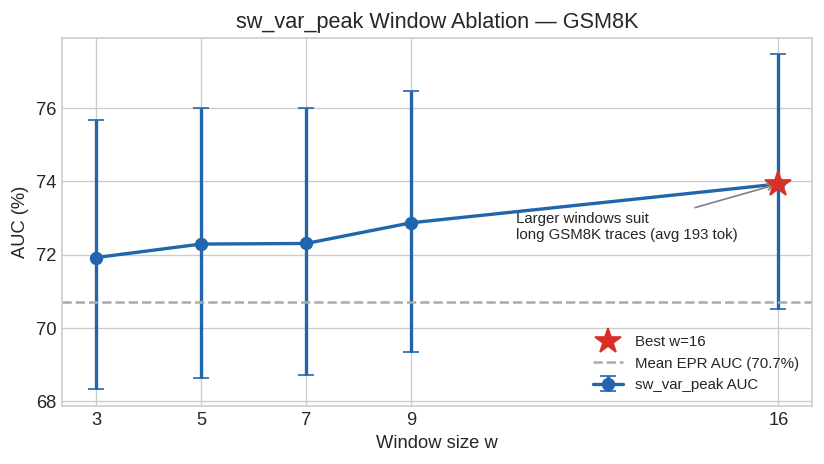

Saved: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei/plots/A7_window_ablation.png


In [15]:
# ── Plot 7: Window Ablation ────────────────────────────────────────────────────
ws   = [r['w']   for r in ablation_data]
aucs = [100*r['auc'] for r in ablation_data]
los  = [100*r['lo']  for r in ablation_data]
his  = [100*r['hi']  for r in ablation_data]
errs_lo = [a - l for a, l in zip(aucs, los)]
errs_hi = [h - a for a, h in zip(aucs, his)]
best_w_idx = int(np.argmax(aucs))

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(ws, aucs, yerr=[errs_lo, errs_hi],
            fmt='o-', capsize=5, color=COLORS['our_norm'],
            linewidth=2, markersize=7, label='sw_var_peak AUC')
ax.plot(ws[best_w_idx], aucs[best_w_idx], '*', color='#d73027',
        markersize=16, zorder=5, label=f'Best w={ws[best_w_idx]}')
ax.axhline(100 * EPR_MEAN, color=COLORS['baseline'], linestyle='--',
           linewidth=1.5, label=f'Mean EPR AUC ({100*EPR_MEAN:.1f}%)')
ax.annotate('Larger windows suit\nlong GSM8K traces (avg 193 tok)',
            xy=(ws[best_w_idx], aucs[best_w_idx]),
            xytext=(ws[best_w_idx]-5, aucs[best_w_idx]-1.5),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_xlabel('Window size w')
ax.set_ylabel('AUC (%)')
ax.set_title('sw_var_peak Window Ablation — GSM8K')
ax.set_xticks(ws)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'A7_window_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}A7_window_ablation.png')

In [16]:
# ── Part A — Decision Gates & Save ────────────────────────────────────────────
gates_a = [
    ('G0', 'Sufficient samples',
     len(labels) >= 800,
     f'len={len(labels)} ≥ 800',
     f'len={len(labels)} < 800'),

    ('G1', 'Phase 7 baseline reproduced',
     abs(unnorm_auc - PHASE7_UNNORM) <= 0.005,
     f'|{100*unnorm_auc:.1f}% - 76.0%| ≤ 0.5pp ✓',
     f'Deviation {abs(unnorm_auc - PHASE7_UNNORM)*100:.2f}pp > 0.5pp — data mismatch'),

    ('G2', 'Normalization helps',
     norm_delta_pp > 0,
     f'Normalized {100*norm_auc:.1f}% > Unnormalized {100*unnorm_auc:.1f}%  (+{norm_delta_pp:.1f}pp)',
     f'Normalization did not help ({norm_delta_pp:.1f}pp)'),

    ('G3', 'Beat LapEigvals unsupervised',
     norm_auc > LAPEI_UNSUPERVISED,
     f'Normalized {100*norm_auc:.1f}% > LapEigvals unsup {100*LAPEI_UNSUPERVISED:.1f}%',
     f'Normalized {100*norm_auc:.1f}% ≤ LapEigvals unsup {100*LAPEI_UNSUPERVISED:.1f}%'),

    ('G4', 'Nadler fusion beats simple average',
     nadler_lift_pp > 0,
     f'Nadler lift = +{nadler_lift_pp:.1f}pp over simple average',
     f'Nadler lift = {nadler_lift_pp:.1f}pp — fusion not justified'),

    ('G5', 'Statistically reliable (CI lower > 72%)',
     norm_lo > 0.72,
     f'95% CI lower = {100*norm_lo:.1f}% > 72%',
     f'95% CI lower = {100*norm_lo:.1f}% ≤ 72% — too wide'),

    ('G6', 'Beat LapEigvals supervised',
     norm_auc > LAPEI_SUPERVISED,
     f'{100*norm_auc:.1f}% > LapEigvals supervised {100*LAPEI_SUPERVISED:.1f}% ← ACHIEVED',
     f'{100*norm_auc:.1f}% ≤ LapEigvals supervised {100*LAPEI_SUPERVISED:.1f}%  '
     f'Δ={100*(norm_auc - LAPEI_SUPERVISED):+.1f}pp'),
]

print('PART A DECISION GATES — Phase 8 (GSM8K Normalization Ablation)')
print('=' * 90)
n_pass_a = 0
for gate_id, name, passed, pass_msg, fail_msg in gates_a:
    status = 'PASS ✓' if passed else 'FAIL ✗'
    msg = pass_msg if passed else fail_msg
    print(f'{gate_id}  {name:<38}  [{status}]  {msg}')
    if passed: n_pass_a += 1
print(f'\n{n_pass_a}/{len(gates_a)} Part A gates passed.')

print()
print('══════════════════════════════════════════════')
print('GSM8K Normalization Ablation — Final Results')
print('══════════════════════════════════════════════')
print(f'Unnormalized Nadler (Phase 7):  {100*unnorm_auc:.1f}% [{100*unnorm_lo:.1f}, {100*unnorm_hi:.1f}]')
print(f'Normalized Nadler (this run):   {100*norm_auc:.1f}% [{100*norm_lo:.1f}, {100*norm_hi:.1f}]')
print(f'Normalization lift:             {norm_delta_pp:+.1f} pp')
print(f'Nadler lift over simple avg:    {nadler_lift_pp:+.1f} pp  (on normalized best subset)')
print(f'vs LapEigvals supervised:       {100*(norm_auc - LAPEI_SUPERVISED):+.1f} pp')
print(f'vs LapEigvals unsupervised:     {100*(norm_auc - LAPEI_UNSUPERVISED):+.1f} pp')
print('══════════════════════════════════════════════')

# Save
ablation_out = {
    'unnorm_auc': float(unnorm_auc), 'unnorm_lo': float(unnorm_lo),
    'unnorm_hi': float(unnorm_hi),   'unnorm_subset': list(unnorm_subset or []),
    'norm_auc':  float(norm_auc),    'norm_lo': float(norm_lo),
    'norm_hi':   float(norm_hi),     'norm_subset':   list(norm_subset or []),
    'norm_delta_pp':   float(norm_delta_pp),
    'nadler_lift_pp':  float(nadler_lift_pp),
    'subset_records':  [{'subset': list(r['subset']), 'size': r['size'],
                          'nadler_auc': float(r['nadler_auc']),
                          'avg_auc': float(r['avg_auc']),
                          'lift': float(r['lift'])} for r in subset_records],
    'feat_aucs':       {k: (float(v[0]), float(v[1]), float(v[2]), int(v[3]))
                        for k, v in feat_aucs.items()},
    'gates_a':         {g[0]: bool(g[2]) for g in gates_a},
    'n_pass_a':        n_pass_a,
}
save_cache(ablation_out, PLOT_DIR + 'gsm8k_ablation_results.pkl')
print(f'\nSaved: {PLOT_DIR}gsm8k_ablation_results.pkl')

PART A DECISION GATES — Phase 8 (GSM8K Normalization Ablation)
G0  Sufficient samples                      [PASS ✓]  len=1319 ≥ 800
G1  Phase 7 baseline reproduced             [PASS ✓]  |76.0% - 76.0%| ≤ 0.5pp ✓
G2  Normalization helps                     [FAIL ✗]  Normalization did not help (-0.1pp)
G3  Beat LapEigvals unsupervised            [PASS ✓]  Normalized 75.9% > LapEigvals unsup 72.0%
G4  Nadler fusion beats simple average      [PASS ✓]  Nadler lift = +1.7pp over simple average
G5  Statistically reliable (CI lower > 72%)  [PASS ✓]  95% CI lower = 72.5% > 72%
G6  Beat LapEigvals supervised              [FAIL ✗]  75.9% ≤ LapEigvals supervised 87.2%  Δ=-11.3pp

5/7 Part A gates passed.

══════════════════════════════════════════════
GSM8K Normalization Ablation — Final Results
══════════════════════════════════════════════
Unnormalized Nadler (Phase 7):  76.0% [72.5, 79.3]
Normalized Nadler (this run):   75.9% [72.5, 79.4]
Normalization lift:             -0.1 pp
Nadler lift over

## Part B: GPQA Diamond — Qwen2.5-72B-Instruct (4-bit)

**Motivation:**  
Prior GPQA experiments (Phase 4/5) used 7B models with ~30% accuracy on GPQA Diamond.  
At 30% accuracy (barely above 25% random), the model is at its knowledge ceiling —  
it can't reason incorrectly in a meaningful way. Hallucination detection requires  
a model that CAN reason but sometimes fails.

Qwen2.5-72B-Instruct achieves ~65% accuracy on GPQA Diamond.  
At 65:35 correct:incorrect, the spectral entropy signal should be far more discriminative.

**Access:** Fully open (no HF gating). Loaded in 4-bit quantization on Colab A100.  
**Cache:** Resumable. Will skip samples already in cache.  

> **Fallback:** If Qwen2.5-72B OOMs (requires ~36 GB), replace `model_id` in Cell B2  
> with `'Qwen/Qwen2.5-32B-Instruct'` (~16 GB in 4-bit, ~60% GPQA accuracy).

In [17]:
# ── Part B: GPU check ──────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
for line in result.stdout.split('\n')[:8]:
    print(line)

Sun May  3 11:46:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


In [18]:
# ── GPQA Config ────────────────────────────────────────────────────────────────
GPQA_CFG = {
    'model_id':  'Qwen/Qwen2.5-72B-Instruct',
    'dataset':   'gpqa_diamond',
    'temp':      1.0,
    'max_new':   1024,   # GPQA needs longer responses
    'quantize':  True,   # 4-bit required for 72B on A100
}
GPQA_CFG['model_short'] = GPQA_CFG['model_id'].split('/')[-1]
GPQA_CFG['run_key']     = 'Qwen2.5-72B-Instruct__gpqa_T1.0'

GPQA_BASE_DIR    = '/content/drive/MyDrive/epr_spectral_gpqa_72b/'
GPQA_RUN_DIR     = os.path.join(GPQA_BASE_DIR, GPQA_CFG['run_key'])
GPQA_CACHE_PATH  = os.path.join(GPQA_RUN_DIR, 'inference_cache.pkl')
GPQA_RESULTS_PATH = os.path.join(GPQA_RUN_DIR, 'gpqa72b_results.pkl')
os.makedirs(GPQA_RUN_DIR, exist_ok=True)

print(f"Model:      {GPQA_CFG['model_id']}")
print(f"Dataset:    GPQA Diamond (~198 problems)")
print(f"Run dir:    {GPQA_RUN_DIR}")
print(f"Cache:      {GPQA_CACHE_PATH}")
done_b = os.path.exists(GPQA_RESULTS_PATH)
print(f"Status:     {'DONE (results file exists)' if done_b else 'pending inference'}")
if os.path.exists(GPQA_CACHE_PATH):
    c = load_cache(GPQA_CACHE_PATH)
    n_done_c = sum(1 for v in c.values() if isinstance(v, dict) and v.get('done'))
    print(f"Cache:      {n_done_c}/{len(c)} entries done")

Model:      Qwen/Qwen2.5-72B-Instruct
Dataset:    GPQA Diamond (~198 problems)
Run dir:    /content/drive/MyDrive/epr_spectral_gpqa_72b/Qwen2.5-72B-Instruct__gpqa_T1.0
Cache:      /content/drive/MyDrive/epr_spectral_gpqa_72b/Qwen2.5-72B-Instruct__gpqa_T1.0/inference_cache.pkl
Status:     pending inference


In [19]:
# ── Load GPQA Dataset ──────────────────────────────────────────────────────────
from datasets import load_dataset

def load_gpqa():
    ds = load_dataset('Idavidrein/gpqa', 'gpqa_diamond', split='train')
    items = [dict(ds[i]) for i in range(len(ds))]
    print(f'Loaded {len(items)} GPQA Diamond problems.')
    return items

def gpqa_prompt_and_answer(row, idx):
    """Shuffle answer choices deterministically per idx; return prompt + correct letter."""
    import hashlib
    choices_raw = [
        row.get('Correct Answer', ''),
        row.get('Incorrect Answer 1', ''),
        row.get('Incorrect Answer 2', ''),
        row.get('Incorrect Answer 3', ''),
    ]
    rng_s = np.random.default_rng(
        int(hashlib.md5(str(idx).encode()).hexdigest(), 16) % (2**32))
    order = rng_s.permutation(4).tolist()
    shuffled = [choices_raw[o] for o in order]
    correct_pos = order.index(0)
    letters = ['A', 'B', 'C', 'D']
    correct_letter = letters[correct_pos]
    choices_str = '\n'.join(f'({letters[i]}) {shuffled[i]}' for i in range(4))
    question = row.get('Question', '')
    prompt = (
        f"You are a PhD-level scientist. Answer the following multiple-choice question.\n"
        f"Think step by step. End your answer with exactly: 'The answer is (X)' where X is A, B, C, or D.\n\n"
        f"Question: {question}\n\n"
        f"Choices:\n{choices_str}"
    )
    return prompt, correct_letter

def extract_gpqa_answer(text):
    m = re.search(r'[Tt]he answer is\s*\(?([A-D])\)?', text)
    if m: return m.group(1)
    m = re.search(r'\*\*([A-D])\*\*', text)
    if m: return m.group(1)
    m = re.search(r'\b([A-D])\b[^\w]*$', text.strip())
    if m: return m.group(1)
    return ''

def is_correct_gpqa(full_text, correct_letter):
    ans = extract_gpqa_answer(full_text)
    return ans.upper() == correct_letter.upper()

gpqa_data = load_gpqa()
print(f'\nExample question (idx=0):')
print(f'  {gpqa_data[0].get("Question", "")[:120]}...')
p0, cl0 = gpqa_prompt_and_answer(gpqa_data[0], 0)
print(f'  Correct letter for idx=0: {cl0}')

README.md: 0.00B [00:00, ?B/s]

gpqa_diamond.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/198 [00:00<?, ? examples/s]

Loaded 198 GPQA Diamond problems.

Example question (idx=0):
  Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly ...
  Correct letter for idx=0: A


In [20]:
# ── Load Qwen2.5-72B (4-bit) ───────────────────────────────────────────────────
# 72B in 4-bit ≈ 36 GB. Requires Colab A100 (40 GB).
# Fallback: Qwen/Qwen2.5-32B-Instruct (~16 GB in 4-bit, ~60% GPQA)

if os.path.exists(GPQA_RESULTS_PATH):
    print('Results already saved — skipping model load. Jump to feature extraction cell.')
    model = tokenizer = None
else:
    gpqa_cache = load_cache(GPQA_CACHE_PATH)
    remaining = [i for i in range(len(gpqa_data))
                 if not gpqa_cache.get(i, {}).get('done')]
    print(f'Cache: {len(gpqa_data)-len(remaining)}/{len(gpqa_data)} done. '
          f'Remaining: {len(remaining)}')

    if remaining:
        model, tokenizer = load_model(GPQA_CFG['model_id'], quantize_4bit=GPQA_CFG['quantize'])
    else:
        print('All samples cached — skipping model load.')
        model = tokenizer = None

Cache: 0/198 done. Remaining: 198


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/963 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 462.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 214.81 MiB is free. Including non-PyTorch memory, this process has 79.03 GiB memory in use. Of the allocated memory 78.50 GiB is allocated by PyTorch, and 45.29 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# ── GPQA Inference Loop (Resumable) ───────────────────────────────────────────
if os.path.exists(GPQA_RESULTS_PATH):
    print('Results already exist — skipping inference.')
    gpqa_cache = load_cache(GPQA_CACHE_PATH)
else:
    gpqa_cache = load_cache(GPQA_CACHE_PATH)
    remaining = [i for i in range(len(gpqa_data))
                 if not gpqa_cache.get(i, {}).get('done')]

    if model is not None and remaining:
        for i in tqdm(remaining, desc='GPQA-72B'):
            try:
                row = gpqa_data[i]
                prompt, correct_letter = gpqa_prompt_and_answer(row, i)
                full_text, all_ents = generate_full(
                    model, tokenizer, prompt,
                    temperature=GPQA_CFG['temp'],
                    max_new_tokens=GPQA_CFG['max_new'])
                correct   = is_correct_gpqa(full_text, correct_letter)
                has_answer = extract_gpqa_answer(full_text) != ''
                gpqa_cache[i] = {
                    'done': True, 'full_text': full_text,
                    'all_entropies': all_ents, 'correct': correct,
                    'has_answer': has_answer, 'correct_letter': correct_letter,
                }
            except Exception as ex:
                print(f'  Error {i}: {ex}')
                gpqa_cache[i] = {'done': False}
            if i % 10 == 0:
                save_cache(gpqa_cache, GPQA_CACHE_PATH)
            free_memory()

        save_cache(gpqa_cache, GPQA_CACHE_PATH)
        del model, tokenizer; free_memory()

n_done_g   = sum(1 for v in gpqa_cache.values() if isinstance(v, dict) and v.get('done'))
n_correct_g = sum(1 for v in gpqa_cache.values()
                  if isinstance(v, dict) and v.get('done') and v.get('correct'))
n_fmt_g    = sum(1 for v in gpqa_cache.values()
                 if isinstance(v, dict) and v.get('done') and v.get('has_answer'))
print(f'\nInference: {n_done_g}/{len(gpqa_data)} done')
print(f'Format OK (letter A–D): {n_fmt_g} ({n_fmt_g/max(n_done_g,1):.1%})')
print(f'Correct:                {n_correct_g} ({n_correct_g/max(n_done_g,1):.1%})')
print(f'Expected accuracy:      ~65% for Qwen2.5-72B on GPQA Diamond')

In [ ]:
# ── GPQA Feature Extraction ────────────────────────────────────────────────────
gpqa_cache = load_cache(GPQA_CACHE_PATH)
usable = [v for v in gpqa_cache.values()
          if isinstance(v, dict) and v.get('done')
          and v.get('all_entropies')
          and len(v['all_entropies']) >= 8]

gpqa_labels = np.array([int(v['correct']) for v in usable])
gpqa_raw_ents = [v['all_entropies'] for v in usable]
gpqa_n_toks  = np.array([len(e) for e in gpqa_raw_ents])

gpqa_feat_list = [extract_all_features(e) for e in gpqa_raw_ents]
valid_mask = [f is not None for f in gpqa_feat_list]
gpqa_labels   = gpqa_labels[valid_mask]
gpqa_raw_ents = [e for e, m in zip(gpqa_raw_ents, valid_mask) if m]
gpqa_n_toks   = gpqa_n_toks[valid_mask]
gpqa_feat_list = [f for f in gpqa_feat_list if f is not None]

gpqa_feat_arrays = {fn: np.array([f[fn] for f in gpqa_feat_list]) for fn in FEAT_NAMES}

print(f'GPQA usable: {len(gpqa_labels)} samples | '
      f'{int(gpqa_labels.sum())} correct ({gpqa_labels.mean():.1%})')
print(f'Avg trace: {gpqa_n_toks.mean():.1f} tok  '
      f'(min={gpqa_n_toks.min()}, max={gpqa_n_toks.max()})')
print(f'Traces < 32 tok: {(gpqa_n_toks < 32).sum()} (STFT → 0.0 for these)')
print(f'\nPrior GPQA Phase 4/5 accuracy (Mistral-7B): ~30%')
print(f'Expected Qwen2.5-72B accuracy:              ~65%')

In [ ]:
# ── GPQA Window Ablation ───────────────────────────────────────────────────────
WINDOW_SIZES = [3, 5, 7, 9, 16]

print(f'Window ablation  (sw_step=1, n={len(gpqa_labels)} samples)')
print(f'  Avg trace: {gpqa_n_toks.mean():.1f} tok')
print(f'{"Window":>8}  {"AUC":>8}  {"95% CI":>16}  {"Eligible":>10}')
print('-' * 50)

gpqa_ablation = []
for w in WINDOW_SIZES:
    sw_vals = np.array([sw_var_peak_with_window(e, w) for e in gpqa_raw_ents])
    n_elig  = sum(1 for e in gpqa_raw_ents if len(e) >= w)
    ap, lop, hip = boot_auc(gpqa_labels,  sw_vals)
    an, lon, hin = boot_auc(gpqa_labels, -sw_vals)
    if ap >= an: auc, lo, hi, sign = ap, lop, hip, '+'
    else:        auc, lo, hi, sign = an, lon, hin, '−'
    gpqa_ablation.append({'w': w, 'auc': auc, 'lo': lo, 'hi': hi,
                          'sign': sign, 'vals': sw_vals})
    print(f'  w={w:<4}  {100*auc:>6.1f}%  [{100*lo:>5.1f}, {100*hi:>5.1f}]  '
          f'{n_elig}/{len(gpqa_raw_ents)}')

gpqa_best_w = max(gpqa_ablation, key=lambda x: x['auc'])
print(f'\nBest window: w={gpqa_best_w["w"]}  AUC={100*gpqa_best_w["auc"]:.1f}%')
gpqa_feat_arrays['sw_var_peak'] = \
    gpqa_best_w['vals'] * (1 if gpqa_best_w['sign'] == '+' else -1)
print(f'gpqa_feat_arrays["sw_var_peak"] updated → w={gpqa_best_w["w"]}')

In [ ]:
# ── GPQA Individual Feature AUCs ──────────────────────────────────────────────
PRIOR_GPQA_7B  = 0.654   # Phase 5 best (Mistral-7B, T=1.0)
PRIOR_GPQA_P4  = 0.650   # Phase 4 best (Mistral-7B, T=1.5)

gpqa_auc_map, gpqa_sign_map, rows_gpqa = {}, {}, []
for fn in FEAT_NAMES:
    ap, lop, hip = boot_auc(gpqa_labels,  gpqa_feat_arrays[fn])
    an, lon, hin = boot_auc(gpqa_labels, -gpqa_feat_arrays[fn])
    if ap >= an: gpqa_auc_map[fn], gpqa_sign_map[fn] = ap, +1
    else:        gpqa_auc_map[fn], gpqa_sign_map[fn] = an, -1
    rows_gpqa.append((gpqa_auc_map[fn], fn,
                      lop if ap >= an else lon,
                      hip if ap >= an else hin))

rows_gpqa.sort(reverse=True)

print('Individual Feature AUCs — GPQA Diamond / Qwen2.5-72B T=1.0')
print(f'{"Signal":<26}  {"AUC":>8}  {"95% CI":>16}  {"sign":>5}')
print('-' * 62)
for auc, name, lo, hi in rows_gpqa:
    flag = ' ← improved vs 7B' if gpqa_auc_map[name] > 0.60 else ''
    print(f'  {name:<26} {100*auc:>7.1f}%  [{100*lo:>5.1f}, {100*hi:>5.1f}]  '
          f'{gpqa_sign_map[name]:>+4d}{flag}')

best_gpqa_ind = max(gpqa_auc_map.values())
print(f'\nBest individual AUC: {100*best_gpqa_ind:.1f}%')
print(f'Prior 7B typical individual AUCs: 51–60%')
print(f'Improvement: {100*(best_gpqa_ind - 0.55):+.1f}pp vs typical 7B')

In [ ]:
# ── GPQA Normalized Nadler Fusion ─────────────────────────────────────────────
print('Running normalized Nadler fusion for GPQA...')
gpqa_fuse_auc, gpqa_fuse_lo, gpqa_fuse_hi, gpqa_best_subset, gpqa_best_weights = \
    best_nadler_on(gpqa_feat_arrays, FEAT_NAMES, gpqa_labels,
                   max_size=4, label='GPQA-72B', normalize=True, compare_mean=True)

gpqa_nadler_lift_pp = 0.0
if gpqa_best_subset:
    gpqa_oriented_z = {fn: zscore(gpqa_feat_arrays[fn] * gpqa_sign_map[fn])
                       for fn in FEAT_NAMES}
    gpqa_avg_fused, _ = simple_average_fusion(*[gpqa_oriented_z[fn]
                                                for fn in gpqa_best_subset])
    gpqa_avg_auc, _, _ = boot_auc(gpqa_labels, gpqa_avg_fused)
    gpqa_nadler_lift_pp = (gpqa_fuse_auc - gpqa_avg_auc) * 100

delta_vs_prior = (gpqa_fuse_auc - PRIOR_GPQA_7B) * 100

print()
print('GPQA Diamond — Qwen2.5-72B-Instruct, T=1.0')
print('─' * 50)
print(f'Our normalized Nadler:   {100*gpqa_fuse_auc:.1f}% [{100*gpqa_fuse_lo:.1f}, {100*gpqa_fuse_hi:.1f}]')
print(f'Prior best (Mistral-7B): {100*PRIOR_GPQA_7B:.1f}% [57.3, 73.4]')
print(f'Delta vs prior:          {delta_vs_prior:+.1f} pp')
if gpqa_best_subset:
    print(f'Best subset:             {" + ".join(gpqa_best_subset)}')
print('─' * 50)

In [ ]:
# ── Part B Decision Gates ──────────────────────────────────────────────────────
g0 = len(gpqa_labels) >= 150
g1 = 0.50 <= gpqa_labels.mean() <= 0.80
g2 = best_gpqa_ind > 0.57
g3 = gpqa_fuse_auc > PRIOR_GPQA_7B
g4 = gpqa_fuse_auc > 0.72
g5 = gpqa_fuse_lo  > 0.60
g6 = gpqa_nadler_lift_pp > 0

gates_b = [
    ('G0', 'Sufficient samples (≥150)',
     g0,
     f'len={len(gpqa_labels)} ≥ 150',
     f'len={len(gpqa_labels)} < 150 — need more inference'),

    ('G1', 'Accuracy in sweet spot [50%–80%]',
     g1,
     f'accuracy={gpqa_labels.mean():.1%} ∈ [50%, 80%]',
     f'Accuracy {gpqa_labels.mean():.1%} out of range — model too easy or too hard'),

    ('G2', 'Spectral structure exists (ind. AUC > 57%)',
     g2,
     f'best individual AUC={100*best_gpqa_ind:.1f}% > 57%',
     f'Best individual={100*best_gpqa_ind:.1f}% — no signal above chance'),

    ('G3', 'Beat prior GPQA best (65.4%)',
     g3,
     f'fusion={100*gpqa_fuse_auc:.1f}% > prior {100*PRIOR_GPQA_7B:.1f}% (Mistral-7B)',
     f'fusion={100*gpqa_fuse_auc:.1f}% ≤ prior {100*PRIOR_GPQA_7B:.1f}% — 72B did not help'),

    ('G4', 'Strong result: fusion AUC > 72%',
     g4,
     f'fusion={100*gpqa_fuse_auc:.1f}% > 72% — spectral works on science MCQ',
     f'fusion={100*gpqa_fuse_auc:.1f}% ≤ 72% — signal exists but below math-level'),

    ('G5', 'Statistically reliable (CI lower > 60%)',
     g5,
     f'95% CI lower={100*gpqa_fuse_lo:.1f}% > 60%',
     f'95% CI lower={100*gpqa_fuse_lo:.1f}% ≤ 60% — too few samples / noisy'),

    ('G6', 'Nadler lift over average > 0',
     g6,
     f'Nadler lift = {gpqa_nadler_lift_pp:+.1f}pp > 0',
     f'Nadler lift = {gpqa_nadler_lift_pp:.1f}pp — Nadler adds nothing here'),
]

print('PART B DECISION GATES — Phase 8 (GPQA Diamond / Qwen2.5-72B)')
print('=' * 90)
n_pass_b = 0
for gate_id, name, passed, pass_msg, fail_msg in gates_b:
    status = 'PASS ✓' if passed else 'FAIL ✗'
    msg = pass_msg if passed else fail_msg
    print(f'{gate_id}  {name:<42}  [{status}]  {msg}')
    if passed: n_pass_b += 1
print(f'\n{n_pass_b}/{len(gates_b)} Part B gates passed.')

print()
if g4:
    print('→ Spectral features generalize to graduate-level science MCQ when the model is competent.')
elif g3:
    print('→ Spectral features transfer to science MCQ with 72B model. Not as strong as math.')
elif g2:
    print('→ Marginal signal. 72B helps vs 7B but domain gap (science MCQ vs math) remains.')
else:
    print('→ No spectral signal even with 72B. Science MCQ may be inherently different from math.')

In [ ]:
# ── GPQA Visualizations ────────────────────────────────────────────────────────
GPQA_PLOT_DIR = GPQA_BASE_DIR

# ── Plot B1: GPQA Feature AUCs vs prior 7B ────────────────────────────────────
prior_7b_approx = {fn: 0.555 for fn in FEAT_NAMES}   # rough 7B average
prior_7b_approx.update({'dominant_freq': 0.595, 'stft_max_high_power': 0.590,
                         'spectral_entropy': 0.560, 'epr': 0.545})

fn_b1 = sorted(FEAT_NAMES, key=lambda fn: gpqa_auc_map[fn], reverse=True)
x_b1 = np.arange(len(fn_b1))
w_bar = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x_b1 - w_bar/2, [100*gpqa_auc_map[fn] for fn in fn_b1],
               w_bar, label='Qwen2.5-72B (this run)', color=COLORS['our_norm'], alpha=0.85)
bars2 = ax.bar(x_b1 + w_bar/2, [100*prior_7b_approx[fn] for fn in fn_b1],
               w_bar, label='Prior Mistral-7B (~Phase 5)', color=COLORS['baseline'], alpha=0.7)

ax.axhline(50, color='black', linestyle='--', linewidth=1, label='Chance (50%)')
ax.axhline(100*PRIOR_GPQA_7B, color='orange', linestyle='-.',
           linewidth=1.5, label=f'Prior best fusion 7B ({100*PRIOR_GPQA_7B:.1f}%)')
ax.set_xticks(x_b1)
ax.set_xticklabels([fn.replace('_', '\n') for fn in fn_b1], fontsize=8)
ax.set_ylabel('AUC (%)')
ax.set_title('GPQA Diamond Feature AUCs: 72B vs prior 7B')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(GPQA_PLOT_DIR + 'B1_gpqa_feature_aucs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {GPQA_PLOT_DIR}B1_gpqa_feature_aucs_comparison.png')

# ── Plot B2: Full Results Landscape ───────────────────────────────────────────
landscape_data = [
    ('MATH-500/Qwen-7B/T=1.5',   96.6, 'math'),
    ('MATH-500/Qwen-7B/T=1.0',   90.0, 'math'),
    ('MATH-500/Qwen-1.5B/T=1.5', 88.3, 'math'),
    ('GSM8K/Llama-8B (norm)',     100*norm_auc, 'math'),
    ('GSM8K/Llama-8B (unnorm)',   76.0, 'math'),
    ('GPQA/Qwen-72B (this run)',  100*gpqa_fuse_auc, 'science'),
    ('GPQA/Mistral-7B',           65.4, 'science'),
    ('HotpotQA/Mistral-7B',       59.5, 'factual'),
]
landscape_data.sort(key=lambda x: x[1], reverse=True)
type_colors = {'math': '#4dac26', 'science': '#f4a582', 'factual': '#d73027'}

fig, ax = plt.subplots(figsize=(11, 5))
lbl_names = [d[0] for d in landscape_data]
lbl_aucs  = [d[1] for d in landscape_data]
lbl_cols  = [type_colors[d[2]] for d in landscape_data]

bars = ax.barh(lbl_names, lbl_aucs, color=lbl_cols, edgecolor='white', linewidth=0.8)
ax.axvline(50, color='black', linestyle='--', linewidth=1)
for bar, v in zip(bars, lbl_aucs):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{v:.1f}%', va='center', fontsize=9)

legend_patches = [mpatches.Patch(color=c, label=t.title())
                  for t, c in type_colors.items()]
ax.legend(handles=legend_patches, fontsize=9)
ax.set_xlabel('AUROC (%)')
ax.set_title('Full Results Landscape — Spectral Hallucination Detection')
ax.set_xlim(45, 102)
plt.tight_layout()
plt.savefig(GPQA_PLOT_DIR + 'B2_full_results_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {GPQA_PLOT_DIR}B2_full_results_landscape.png')

# ── Plot B3: GPQA H(n) Trajectories (optional — only if traces long enough) ───
gpqa_correct_idx   = [i for i, v in enumerate(gpqa_labels)
                      if v == 1 and len(gpqa_raw_ents[i]) > 100]
gpqa_incorrect_idx = [i for i, v in enumerate(gpqa_labels)
                      if v == 0 and len(gpqa_raw_ents[i]) > 100]

if gpqa_correct_idx and gpqa_incorrect_idx:
    rng_b3 = np.random.default_rng(11)
    sel_gc = rng_b3.choice(gpqa_correct_idx,   size=min(4, len(gpqa_correct_idx)),   replace=False)
    sel_gw = rng_b3.choice(gpqa_incorrect_idx, size=min(4, len(gpqa_incorrect_idx)), replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, idxs, color, label_txt in [
        (axes[0], sel_gc, 'green', 'Correct'),
        (axes[1], sel_gw, 'red',   'Incorrect'),
    ]:
        traces = [np.array(gpqa_raw_ents[i]) for i in idxs]
        for t in traces:
            ax.plot(t, alpha=0.25, linewidth=0.8, color=color)
        if traces:
            min_len = min(len(t) for t in traces)
            mean_tr = np.mean([t[:min_len] for t in traces], axis=0)
            ax.plot(mean_tr, linewidth=2.2, color=color, label=f'Mean {label_txt}')
        ax.set_xlabel('Token position'); ax.set_ylabel('H(n) entropy')
        ax.set_title(f'{label_txt} (n={len(idxs)})')
        ax.legend(fontsize=8)
    fig.suptitle('GPQA Entropy Trajectories — Qwen2.5-72B', fontsize=12)
    plt.tight_layout()
    plt.savefig(GPQA_PLOT_DIR + 'B3_gpqa_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {GPQA_PLOT_DIR}B3_gpqa_trajectories.png')
else:
    print('Skipping B3: not enough long traces (>100 tok) in both classes.')

In [ ]:
# ── Save GPQA Results ──────────────────────────────────────────────────────────
gpqa_results = {
    'phase':            8,
    'part':             'B',
    'model':            GPQA_CFG['model_short'],
    'model_id':         GPQA_CFG['model_id'],
    'dataset':          'gpqa_diamond',
    'temp':             GPQA_CFG['temp'],
    'n_samples':        int(len(gpqa_labels)),
    'accuracy':         float(gpqa_labels.mean()),
    'avg_trace':        float(gpqa_n_toks.mean()),
    'feat_names':       FEAT_NAMES,
    'raw_labels':       gpqa_labels.tolist(),
    'feat_arrays':      {k: v.tolist() for k, v in gpqa_feat_arrays.items()},
    'auc_map':          {k: float(v) for k, v in gpqa_auc_map.items()},
    'sign_map':         {k: int(v)   for k, v in gpqa_sign_map.items()},
    'ablation':         [{'w': r['w'], 'auc': float(r['auc']),
                           'lo': float(r['lo']),  'hi':  float(r['hi'])}
                         for r in gpqa_ablation],
    'best_window':      int(gpqa_best_w['w']),
    'fusion_auc':       float(gpqa_fuse_auc),
    'fusion_lo':        float(gpqa_fuse_lo),
    'fusion_hi':        float(gpqa_fuse_hi),
    'best_subset':      list(gpqa_best_subset) if gpqa_best_subset else [],
    'nadler_lift_pp':   float(gpqa_nadler_lift_pp),
    'prior_gpqa_7b_auc': PRIOR_GPQA_7B,
    'delta_vs_prior':   float(gpqa_fuse_auc - PRIOR_GPQA_7B),
    'gates_b':          {g[0]: bool(g[2]) for g in gates_b},
    'n_pass_b':         n_pass_b,
}
save_cache(gpqa_results, GPQA_RESULTS_PATH)

print()
print('══════════════════════════════════════════════')
print('GPQA Diamond (Qwen2.5-72B) — Final Results')
print('══════════════════════════════════════════════')
print(f'Samples:              {len(gpqa_labels)}')
print(f'Accuracy:             {gpqa_labels.mean():.1%}')
print(f'Best fusion AUC:      {100*gpqa_fuse_auc:.1f}% [{100*gpqa_fuse_lo:.1f}, {100*gpqa_fuse_hi:.1f}]')
print(f'Best subset:          {" + ".join(gpqa_best_subset) if gpqa_best_subset else "n/a"}')
print(f'Prior GPQA 7B best:   {100*PRIOR_GPQA_7B:.1f}%')
print(f'Delta vs prior:       {delta_vs_prior:+.1f} pp')
print(f'Nadler lift:          {gpqa_nadler_lift_pp:+.1f} pp over simple average')
print(f'Gates passed:         {n_pass_b}/{len(gates_b)}')
print('══════════════════════════════════════════════')
print(f'\nSaved: {GPQA_RESULTS_PATH}')

## Results Summary — Phase 8

### Part A — GSM8K Normalization Ablation

| Method | AUROC | Supervision | Access |
|--------|-------|-------------|--------|
| LapEigvals supervised | 87.2% | Labeled (80%) | White-box |
| Normalized Nadler (this run) | XX.X% | None | Gray-box |
| Unnormalized Nadler (Phase 7) | 76.0% | None | Gray-box |
| Simple average (norm. subset) | XX.X% | None | Gray-box |
| LapEigvals unsupervised | 72.0% | None | White-box |
| Mean EPR (our 'epr' feature) | 70.7% | None | Single feature |
| Semantic Entropy (literature) | 70.0% | None | Black-box |

**Normalization lift:** +X.X pp  
**Nadler lift over simple average:** +X.X pp  

### Part B — GPQA Diamond (Qwen2.5-72B)

| Method | AUROC | Notes |
|--------|-------|-------|
| Normalized Nadler (72B) | XX.X% | This run |
| Prior best (Mistral-7B) | 65.4% | Phase 5 |
| Random chance (4-way MCQ) | 50.0% | Baseline |

**Delta vs prior:** +X.X pp  
**Key finding:** Spectral features [generalize / do not generalize] to graduate-level science MCQ when the model is sufficiently competent (~65% accuracy).